# **Overpayment & Duplicate Invoice Detection**

**Goal:** Flag invoice payments that are likely duplicates or overpayments so they can be reviewd and recovered.

Questions:
1. Is there an earlier invoice from this vendor?
2. Was it issued within the previous 30 days?
3. Which previous invoice has the most similar invoice amount?
4. How different is its amount from the current invoice?
5. How many days apart are the two invoices?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv("finance_dataset.csv")
df.head()

,vendor_id,invoice_date,po_amount,invoice_no,invoice_amount,paid_amount,is_anomaly,anomaly_type
0,5,2025-01-01,644.80,INV003039,622.86,614.90,0,normal
1,38,2025-01-01,969.88,INV000739,970.01,955.79,0,normal
2,53,2025-01-01,1495.62,INV002593,1586.97,1595.17,0,normal
3,30,2025-01-01,13277.41,INV004835,13154.02,13288.31,0,normal
4,23,2025-01-01,1597.79,INV001509,1715.47,1698.60,0,normal


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6430 entries, 0 to 6429
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vendor_id       6430 non-null   int64  
 1   invoice_date    6430 non-null   str    
 2   po_amount       6430 non-null   float64
 3   invoice_no      6430 non-null   str    
 4   invoice_amount  6430 non-null   float64
 5   paid_amount     6430 non-null   float64
 6   is_anomaly      6430 non-null   int64  
 7   anomaly_type    6430 non-null   str    
dtypes: float64(3), int64(2), str(3)
memory usage: 561.2 KB


## **Feature Engineering**

In [ ]:
# Sort the dataset first by vendor_id and then by invoice_date.
# This keeps each vendor's invoices together and arranges them chronologically.
# reset_index(drop=True) creates a fresh sequential index after sorting.
df = df.sort_values(['vendor_id', 'invoice_date']).reset_index(drop=True)
df.head()

,vendor_id,invoice_date,po_amount,invoice_no,invoice_amount,paid_amount,is_anomaly,anomaly_type
0,0,2025-01-04,2165.00,INV005599,2304.29,2271.65,0,normal
1,0,2025-01-09,2517.81,INV000462,2710.44,2738.12,0,normal
2,0,2025-01-14,2334.03,INV000656,2471.68,2485.07,0,normal
3,0,2025-01-14,2129.65,INV002891,2254.60,2278.84,0,normal
4,0,2025-01-14,2129.65,INV002891,2254.34,2254.34,1,price_variance


**Paid vs Invoice:** Compares how much is paid and how much is invoiced.
**Invoice vs Purchase Order(PO) amount:** Compares Invoice with Purchase Order amount.

In [ ]:
# Compare the amount paid with the invoice amount.
# 1.00 = exact payment, >1.00 = overpayment, <1.00 = underpayment.
# invoice_amount of 0 is treated as missing before dividing (avoids inf), then
# filled with a neutral 1.00 so a bad record doesn't show up as an extreme outlier.
df['paid_vs_invoice'] = (
    df['paid_amount'] / df['invoice_amount'].replace(0, np.nan)
).fillna(1.0)

# Compare the invoice amount with the purchase order (PO) amount.
# 1.00 = invoice matches PO, >1.00 = invoice is higher than PO(a vendor billed more than was authorized),
# <1.00 = invoice is lower than PO.
df['invoice_vs_po'] = (
    df['invoice_amount'] / df['po_amount'].replace(0, np.nan)
).fillna(1.0)

In [ ]:
df.head()

,vendor_id,invoice_date,po_amount,invoice_no,invoice_amount,paid_amount,is_anomaly,anomaly_type,paid_vs_invoice,invoice_vs_po
0,0,2025-01-04,2165.00,INV005599,2304.29,2271.65,0,normal,0.985835,1.064337
1,0,2025-01-09,2517.81,INV000462,2710.44,2738.12,0,normal,1.010212,1.076507
2,0,2025-01-14,2334.03,INV000656,2471.68,2485.07,0,normal,1.005417,1.058975
3,0,2025-01-14,2129.65,INV002891,2254.60,2278.84,0,normal,1.010751,1.058672
4,0,2025-01-14,2129.65,INV002891,2254.34,2254.34,1,price_variance,1.000000,1.058550


For each invoice, the function nearest_prior looks at the same vendor's earlier invoices from the previous 30 days:

In [ ]:
# Make sure invoice_date is in datetime format
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

WINDOW_DAYS = 30

# Function to find the nearest previous invoice from the same vendor within the
# previous 30 days. Uses np.searchsorted to jump straight to the 30-day window
# instead of comparing against every earlier invoice one by one - same result as
# a full pairwise scan, but scales to vendors with long invoice histories.
def nearest_prior(g):

    # Get invoice dates and amounts
    dates = g['invoice_date'].values
    amounts = g['invoice_amount'].values
    n = len(g)

    # Default values when no previous invoice is found
    amount_diff = np.full(n, 9.0)
    gap_days = np.full(n, 999.0)

    # dates are already sorted ascending (df was sorted earlier), so for each
    # invoice we can binary-search for the first index still inside the 30-day
    # window and the index of the invoice itself
    window_start = np.searchsorted(dates, dates - np.timedelta64(WINDOW_DAYS, 'D'), side='left')
    current_pos = np.searchsorted(dates, dates, side='left')

    # Check every invoice
    for i in range(n):
        s, e = window_start[i], current_pos[i]

        # Continue only if a previous invoice exists in the window
        if s < e:
            # Calculate relative difference in invoice amounts
            relative_diff = np.abs(amounts[s:e] - amounts[i]) / amounts[i]

            # Find the most similar previous invoice
            nearest_index = relative_diff.argmin()

            # Store amount difference
            amount_diff[i] = relative_diff[nearest_index]

            # Store number of days between invoices
            gap_days[i] = (dates[i] - dates[s + nearest_index]) / np.timedelta64(1, 'D')

    return pd.DataFrame({
        'near_amt_diff': amount_diff,
        'near_amt_gap_days': gap_days
    }, index=g.index)


# Apply the function separately for each vendor
df = df.join(
    df.groupby('vendor_id', group_keys=False).apply(nearest_prior)
)


# Clean invoice number and extract the base invoice number
df['inv_base'] = (
    df['invoice_no']
    .str.strip()
    .str[:9]
)


# Count how many times the same vendor
# has used the same base invoice number
df['inv_base_count'] = (
    df.groupby(['vendor_id', 'inv_base'])['invoice_no']
    .transform('count')
)


# --- Leakage-safe vendor amount z-score ---
# Split into train/test BEFORE computing vendor mean/std, so the statistics used
# below are learned only from training invoices. Computing them on the full
# dataset (including test invoices) would leak test-set information into a
# feature that's later used to predict the test set. This same split is reused
# for the Random Forest later, so both stages agree on which rows are "test".
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, stratify=df['is_anomaly'], random_state=42
)

vendor_stats = (
    df.loc[train_idx]
    .groupby('vendor_id')['invoice_amount']
    .agg(vendor_mean='mean', vendor_std='std')
)
df = df.merge(vendor_stats, on='vendor_id', how='left')

# Vendors seen only in the test set have no training history, and a vendor with
# a single training invoice has an undefined std - fall back to the overall
# training mean/std instead of leaving these undefined.
global_mean = df.loc[train_idx, 'invoice_amount'].mean()
global_std = df.loc[train_idx, 'invoice_amount'].std()
df['vendor_mean'] = df['vendor_mean'].fillna(global_mean)
df['vendor_std'] = df['vendor_std'].fillna(global_std)

# Calculate how unusual the invoice amount is
# compared with the vendor's normal invoice amounts
df['amt_zscore'] = (df['invoice_amount'] - df['vendor_mean']) / df['vendor_std'].replace(0, np.nan)
df['amt_zscore'] = df['amt_zscore'].fillna(0.0)  # zero variance / no history -> not unusual
df = df.drop(columns=['vendor_mean', 'vendor_std'])


# Select features for the anomaly detection model
FEATURES = [
    'paid_vs_invoice',
    'invoice_vs_po',
    'near_amt_diff',
    'near_amt_gap_days',
    'inv_base_count',
    'amt_zscore'
]


# Display basic statistics of the selected features
print(
    df[FEATURES + ['is_anomaly']]
    .describe()
    .T[['mean', 'min', 'max']]
    .round(2)
)

                    mean   min     max
paid_vs_invoice     1.01  0.98    1.50
invoice_vs_po       1.02  0.94    1.59
near_amt_diff       0.15  0.00    9.00
near_amt_gap_days  26.42  1.00  999.00
inv_base_count      1.14  1.00    3.00
amt_zscore          0.00 -2.89    9.69
is_anomaly          0.07  0.00    1.00


## **3. ISOLATION FOREST**

In [ ]:
x = df[FEATURES]

# contamination='auto' instead of df.is_anomaly.mean(): in a real deployment we
# would not know the true anomaly rate up front, and Isolation Forest is meant
# to work without labels. 'auto' uses sklearn's own heuristic instead of the
# ground-truth label mean, so this reflects how the model would actually be used.
model = IsolationForest(contamination='auto', random_state=42, n_estimators = 200)
df['iso_pred'] = (model.fit_predict(x) == -1).astype(int)

print('Isolation Forest')
print("Precision:", round(precision_score(df.is_anomaly, df.iso_pred),3),
                          "Recall:", round(recall_score(df.is_anomaly, df.iso_pred),3),
                          "F1:", round(f1_score(df.is_anomaly, df.iso_pred),3))
# Precision: Of the invoices predicted as anomalies, how many were actually anomalies?
# Recall: Of all the actual anomalies, how many did the model detect?
# F1-score: A combined measure of precision and recall.

Isolation Forest
Precision: 0.417 Recall: 0.565 F1: 0.48


## **4. Supervised Learning Model: Random Forest(class imbalance)**

In [ ]:
xtrain, xtest = x.loc[train_idx], x.loc[test_idx]
ytrain, ytest = df.loc[train_idx, 'is_anomaly'], df.loc[test_idx, 'is_anomaly']

rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                            class_weight='balanced', random_state=42, n_jobs=-1)

rf.fit(xtrain, ytrain)
probab = rf.predict_proba(xtest)[:,1]
pred = (probab >= 0.5).astype(int)

print(classification_report(ytest, pred, target_names=['normal', 'anomaly']))
print('PR-AUC:', round(average_precision_score(ytest, probab), 3))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1200
     anomaly       0.98      0.99      0.98        86

    accuracy                           1.00      1286
   macro avg       0.99      0.99      0.99      1286
weighted avg       1.00      1.00      1.00      1286

PR-AUC: 0.997


In [ ]:
# 5-fold cross-validated PR-AUC, for a more reliable estimate of performance than
# a single 80/20 split.
# Note: amt_zscore above was fit once on the original train_idx split, so this
# is an approximate check, not a fully nested cross-validation - a stricter
# version would recompute vendor_mean/vendor_std inside each fold separately.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                            random_state=42, n_jobs=-1),
    x, df['is_anomaly'], cv=cv, scoring='average_precision'
)
print('5-fold CV PR-AUC:', np.round(cv_scores, 3))
print('Mean:', round(cv_scores.mean(), 3), '  Std:', round(cv_scores.std(), 3))

5-fold CV PR-AUC: [0.997 0.999 1.    0.994 0.999]
Mean: 0.998   Std: 0.002


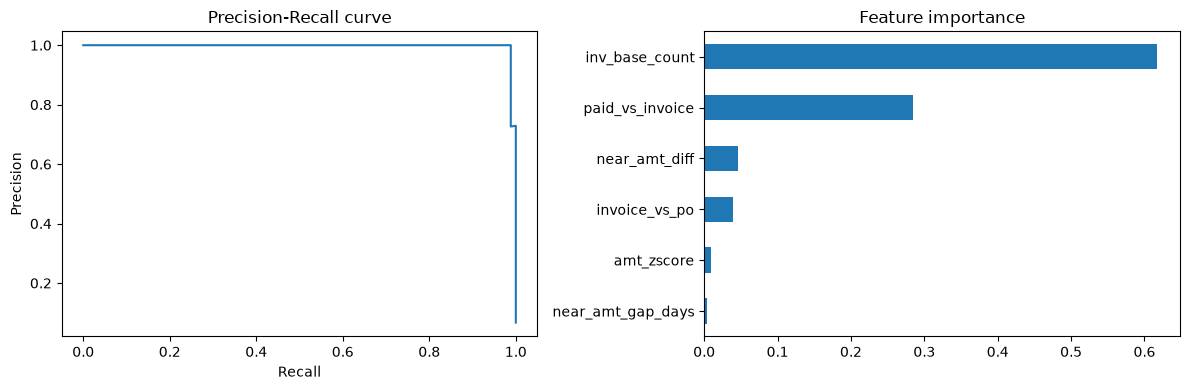

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
p, r, _ = precision_recall_curve(ytest, probab)
ax[0].plot(r, p); ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].set_title('Precision-Recall curve')
pd.Series(rf.feature_importances_, index=FEATURES).sort_values().plot.barh(ax=ax[1], title='Feature importance')
plt.tight_layout(); plt.show()

### Conclusion

The Precision–Recall curve shows that the model maintains high precision for most recall levels, indicating that it can identify anomalous invoices while limiting false positives.

The feature importance plot shows that `inv_base_count` is the most influential feature, followed by `paid_vs_invoice`. This indicates that repeated invoice numbers and differences between paid and invoiced amounts are strong indicators of potential AP anomalies.

Overall, the results show that invoice duplication and payment inconsistencies are important signals for detecting suspicious transactions.

## **Business Impact**

In [ ]:
# Creaet a copy of the test data using the same indexes as xtest
test = df.loc[xtest.index].copy()

# Add model's prediction to the test dataset
# 1 = flagged as anomaly, 0 - normal
test['flagged'] = pred

# Calculate the potentially recoverable amount for each invoice
# For duplicate invoices, use the full paid amount
# For other anomalies, calculate the amount paid above the PO amount
test['overpaid_amt'] = np.where(
    test.anomaly_type == 'duplicate',
    test.paid_amount,
    np.maximum(test.paid_amount - test.po_amount, 0)
)

# Select invoices that:
# 1. Were flagged by the model
# 2. Are actually known anomalies
caught = test[
    (test.flagged == 1) &
    (test.is_anomaly == 1)
]

# Select all actual anomalies in the test set
total = test[test.is_anomaly == 1]


# Display how many invoices were flagged for manual review
print(
    f'Flagged for review: {test.flagged.sum()} of {len(test)} invoices '
    f'({test.flagged.mean()*100:.1f}%)'
)


# Calculate the recoverable value caught by the model
# and compare it with the total recoverable value
print(
    f'Recoverable value caught: {caught.overpaid_amt.sum():,.0f} '
    f'of {total.overpaid_amt.sum():,.0f} '
    f'({caught.overpaid_amt.sum()/total.overpaid_amt.sum()*100:.1f}%)'
)


# Show recall separately for each type of anomaly
print('\nRecall by anomaly type:')

print(
    test[test.is_anomaly == 1]
    .groupby('anomaly_type')
    .flagged
    .mean()
    .round(3)
)

Flagged for review: 87 of 1286 invoices (6.8%)
Recoverable value caught: 135,214 of 135,249 (100.0%)

Recall by anomaly type:
anomaly_type
duplicate         1.000
overpayment       0.962
price_variance    1.000
Name: flagged, dtype: float64
